incerc sa fac mnist sa vedem daca pot 


nu cred

In [7]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) 
])


train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)


In [8]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size = 64, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)


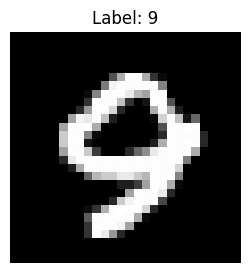

In [9]:
import matplotlib.pyplot as plt

dataiter = iter(train_loader)
images, labels = next(dataiter)


img = images[0]
label = labels[0].item()

plt.figure(figsize=(3, 3))
plt.imshow(img.squeeze(), cmap="gray")
plt.title(f"Label: {label}")
plt.axis("off") 
plt.show()


In [19]:
# clasa pentru cap
import torch.nn.functional as F


class MnistNN(nn.Module):
    def __init__(self):
        super(MnistNN, self).__init__()

        self.flatten = nn.Flatten()

        self.hidden_layer1 = nn.Linear(28 * 28, 128)

        self.hidden_layer2 = nn.Linear(128, 64)

        self.output_layer = nn.Linear(64, 10)

    
    def forward(self, batch):

        batch = self.flatten(batch)
        batch = F.relu(self.hidden_layer1(batch))
        batch = F.relu(self.hidden_layer2(batch))

        batch = self.output_layer(batch)
        return batch



device = torch.device("cpu")
model = MnistNN().to(device)
print("intialized model")




intialized model


In [21]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 5

for epoch in range(epochs):
    running_loss = 0.0
     
    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()
        if i % 100 == 99:    
            print(f'[Epoch {epoch + 1}, Batch {i + 1}] loss: {running_loss / 100:.3f}')
            running_loss = 0.0
            
print("finished training")


[Epoch 1, Batch 100] loss: 0.170
[Epoch 1, Batch 200] loss: 0.168
[Epoch 1, Batch 300] loss: 0.160
[Epoch 1, Batch 400] loss: 0.135
[Epoch 1, Batch 500] loss: 0.138
[Epoch 1, Batch 600] loss: 0.144
[Epoch 1, Batch 700] loss: 0.150
[Epoch 1, Batch 800] loss: 0.136
[Epoch 1, Batch 900] loss: 0.133
[Epoch 2, Batch 100] loss: 0.118
[Epoch 2, Batch 200] loss: 0.112
[Epoch 2, Batch 300] loss: 0.117
[Epoch 2, Batch 400] loss: 0.123
[Epoch 2, Batch 500] loss: 0.120
[Epoch 2, Batch 600] loss: 0.125
[Epoch 2, Batch 700] loss: 0.104
[Epoch 2, Batch 800] loss: 0.115
[Epoch 2, Batch 900] loss: 0.105
[Epoch 3, Batch 100] loss: 0.103
[Epoch 3, Batch 200] loss: 0.096
[Epoch 3, Batch 300] loss: 0.106
[Epoch 3, Batch 400] loss: 0.098
[Epoch 3, Batch 500] loss: 0.089
[Epoch 3, Batch 600] loss: 0.100
[Epoch 3, Batch 700] loss: 0.102
[Epoch 3, Batch 800] loss: 0.105
[Epoch 3, Batch 900] loss: 0.098
[Epoch 4, Batch 100] loss: 0.080
[Epoch 4, Batch 200] loss: 0.079
[Epoch 4, Batch 300] loss: 0.084
[Epoch 4, 

In [22]:
correct = 0
total = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the 10,000 test images: {100 * correct / total:.2f}%')

Accuracy of the network on the 10,000 test images: 97.20%
